In [2]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ROOT
from snewpy.models.ccsn import Nakazato_2013, Bollig_2016
from snewpy.neutrino import Flavor, MassHierarchy
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW

# --- Initialize Supernova Models ---
nakazato = Nakazato_2013(
    progenitor_mass=20 * u.solMass,
    revival_time=100 * u.ms,
    metallicity=0.004,
    eos='shen'
)
bollig = Bollig_2016(progenitor_mass=27 * u.solMass)

models = {"Nakazato": nakazato, "Bollig": bollig}

# --- Define Neutrino Oscillation Scenarios ---
transforms = {
    "No Oscillations": NoTransformation(),
    #"Normal Hierarchy": AdiabaticMSW(mh=MassHierarchy.NORMAL),
    #"Inverted Hierarchy": AdiabaticMSW(mh=MassHierarchy.INVERTED)
}

# --- Common Setup ---
E_bins = np.linspace(0, 100, 200) * u.MeV
E_centers = (E_bins[:-1] + E_bins[1:]) / 2
flavor = Flavor.NU_E

# --- Loop Over Models ---
for model_name, model in models.items():
    times = model.time.to_value(u.s)

    # --- Plot Luminosity, Mean Energy, and Pinching Parameter ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(times, model.luminosity[flavor].to_value(u.erg / u.s))
    plt.xlabel("Time [s]")
    plt.ylabel("Luminosity [erg/s]")
    plt.title(f"{model_name} νe Luminosity")
    plt.grid()

    plt.subplot(1, 3, 2)
    plt.plot(times, model.meanE[flavor].to_value(u.MeV))
    plt.xlabel("Time [s]")
    plt.ylabel("Mean Energy [MeV]")
    plt.title(f"{model_name} νe Mean Energy")
    plt.grid()

    plt.subplot(1, 3, 3)
    plt.plot(times, model.pinch[flavor])
    plt.xlabel("Time [s]")
    plt.ylabel("Pinch α")
    plt.title(f"{model_name} νe Pinch Parameter")
    plt.grid()
    plt.tight_layout()
    plt.show()

    # --- Spectra and Integrations ---
    for label, transform in transforms.items():
        spectra = model.get_transformed_spectra(model.time, E_bins, transform)
        spec_nue = spectra[flavor].to_value(1 / (u.s * u.MeV))  # time × energy array

        # --- 2D Spectrum Heatmap ---
        plt.figure(figsize=(6, 4))
        plt.pcolormesh(times, E_bins.to_value(u.MeV), spec_nue.T, shading='auto')
        plt.xlabel("Time [s]")
        plt.ylabel("Energy [MeV]")
        plt.title(f"{model_name} νe Spectrum — {label}")
        plt.colorbar(label="dN/dE [#/s/MeV]")
        plt.xlim(-0.05, 0.25)
        plt.ylim(0, 60)
        plt.tight_layout()
        plt.show()

        # --- Integrate Over Time to Get dN/dE ---
        counts_vs_energy = np.trapz(spec_nue, x=times, axis=0)  # shape: (n_E,)
        counts_vs_energy = counts_vs_energy[:-1]  # match length to bin centers

        # --- Integrate Over Energy to Get Total Flux vs Time ---
        flux_vs_time = np.trapz(spec_nue, x=E_bins.to_value(u.MeV), axis=1)

        # --- Plot: Counts vs Energy (Time-Integrated) ---
        plt.figure(figsize=(7, 5))
        plt.step(E_centers.to_value(u.MeV), counts_vs_energy, where='mid')
        plt.xlabel("Energy [MeV]")
        plt.ylabel("Counts [#/MeV]")
        plt.title(f"{model_name} νe Time-Integrated Counts — {label}")
        plt.grid()
        plt.tight_layout()
        plt.show()

        # --- Plot: Flux vs Time (Energy-Integrated) ---
        plt.figure(figsize=(7, 5))
        plt.plot(times, flux_vs_time, marker='.', linestyle='-')
        plt.xlabel("Time [s]")
        plt.ylabel("Integrated Flux [#/s]")
        plt.title(f"{model_name} νe Energy-Integrated Flux — {label}")
        plt.grid()
        plt.tight_layout()
        plt.show()
        
               # --- Create a ROOT file per model ---
        filename = f"supernova_counts_{model_name}.root"
        root_file = ROOT.TFile(filename, "RECREATE")

        # Create histogram
        hist_name = f"counts_{model_name}_{label}".replace(" ", "_")

        th1 = ROOT.TH1D(
            hist_name,
            f"{model_name} νe Time-Integrated Counts — {label}",
            len(E_centers),
            E_centers[0].value,
            E_centers[-1].value
        )

        # Fill histogram
        for i, val in enumerate(counts_vs_energy):
            th1.SetBinContent(i + 1, val)

        # Write histogram and close file
        th1.Write()
        root_file.Close()

        print(f"Saved histogram to: {filename}")


ModuleNotFoundError: No module named 'matplotlib'

In [1]:
pip install astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 13.8 MB/s eta 0:00:0031m14.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 14.8 MB/s eta 0:00:0031m16.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 17.0 MB/s eta 0:00:000:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 738.7/738.7 kB 16.9 MB/s eta 0:00:0031m17.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 16.4 MB/s eta 0:00:0031m15.3 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
"""""
    # Save model parameters to CSV
    df = pd.DataFrame({
        "time_s": times,
        "luminosity_erg_per_s": model.luminosity[flavor].to_value(u.erg / u.s),
        "mean_energy_MeV": model.meanE[flavor].to_value(u.MeV),
        "alpha": model.pinch[flavor]
    })
    filename = f"{model_name}_nu_e_timeseries.csv"
    df.to_csv(filename, index=False)
    print(f"✅ Saved {filename}")
"""""



 if label == "No Oscillations":
            root_filename = f"{model_name}_nu_e_NoOsc.root"
            f = ROOT.TFile(root_filename, "RECREATE")

            nt = len(times)
            ne = len(E_bins) - 1

            h2 = ROOT.TH2D(f"nusperbin2d_{model_name}_nue",
                   f"νe Flux {model_name};Time [s];Energy [MeV]",
                   nt, times.min(), times.max(),
                   ne, E_bins[0].to_value(u.MeV), E_bins[-1].to_value(u.MeV))

    # Fill histogram
    for i_t in range(nt):
        for i_e in range(ne):
            h2.SetBinContent(i_t+1, i_e+1, spec_nue[i_t, i_e])

    h2.Write()
    f.Close()
    print(f"💾 Saved 2D νe flux histogram: {root_filename}")

In [10]:
import ROOT

# --- EDIT THESE ---
filename   = "supernova_counts_Nakazato.root"
hist_name  = "counts_Nakazato_No_Oscillations"
# ------------------

f = ROOT.TFile.Open(filename)
h = f.Get(hist_name)

if not h:
    raise RuntimeError(f"Histogram {hist_name} not found in {filename}")

energies = []
weights = []

# Loop over bins
for i in range(1, h.GetNbinsX()+1):
    energies.append(h.GetBinCenter(i))
    weights.append(h.GetBinContent(i))

# --- Helper to print 4 items per line ---
def print_four_per_line(label, arr):
    print(f"{label} = [")
    for i, v in enumerate(arr):
        end = "\n" if (i + 1) % 4 == 0 else " "
        print(f"{v:.8g},", end=end)
    if len(arr) % 4 != 0:
        print()  # final newline if needed
    print("]\n")

# --- Print results ---
print_four_per_line("ENERGIES", energies)
print_four_per_line("WEIGHTS", weights)


ENERGIES = [
0.50124997, 1.0012373, 1.5012247, 2.0012121,
2.5011995, 3.0011868, 3.5011742, 4.0011616,
4.501149, 5.0011363, 5.5011237, 6.0011111,
6.5010985, 7.0010858, 7.5010732, 8.0010606,
8.501048, 9.0010353, 9.5010227, 10.00101,
10.500997, 11.000985, 11.500972, 12.00096,
12.500947, 13.000934, 13.500922, 14.000909,
14.500896, 15.000884, 15.500871, 16.000859,
16.500846, 17.000833, 17.500821, 18.000808,
18.500795, 19.000783, 19.50077, 20.000758,
20.500745, 21.000732, 21.50072, 22.000707,
22.500694, 23.000682, 23.500669, 24.000657,
24.500644, 25.000631, 25.500619, 26.000606,
26.500593, 27.000581, 27.500568, 28.000556,
28.500543, 29.00053, 29.500518, 30.000505,
30.500492, 31.00048, 31.500467, 32.000455,
32.500442, 33.000429, 33.500417, 34.000404,
34.500391, 35.000379, 35.500366, 36.000354,
36.500341, 37.000328, 37.500316, 38.000303,
38.50029, 39.000278, 39.500265, 40.000253,
40.50024, 41.000227, 41.500215, 42.000202,
42.500189, 43.000177, 43.500164, 44.000152,
44.500139, 45.000126, 45.500

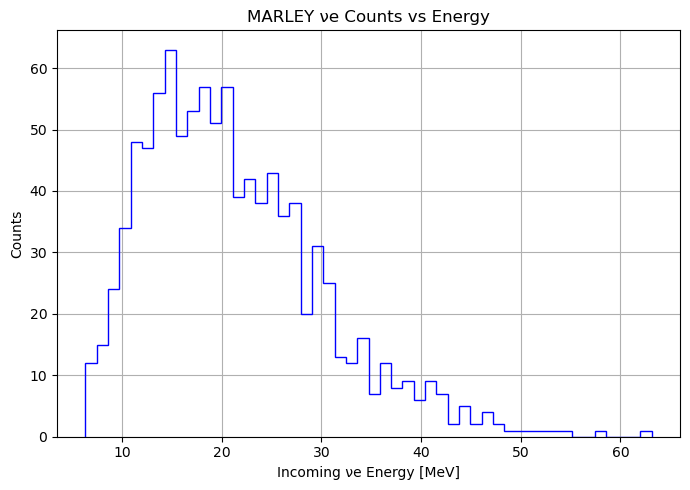

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Path to your MARLEY ASCII event file
filename = "/home/argon/Projects/Ilker/marley/examples/config/events.ascii"

# Lists to store energies
nu_e_energies = []

with open(filename, "r") as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i].strip()
    if not line or line.startswith("#"):  # skip empty or comment lines
        i += 1
        continue

    tokens = line.split()
    # Event header line typically starts a new event
    if len(tokens) >= 4:
        # Next line(s) contain initial state particles
        j = i + 1
        while j < len(lines):
            parts = lines[j].strip().split()
            if len(parts) == 0:
                j += 1
                continue
            pdg = int(parts[0])
            # PDG 12 = electron neutrino
            if pdg == 12:
                energy = float(parts[1])
                nu_e_energies.append(energy)
                break  # found incoming neutrino for this event
            j += 1
        i = j
    else:
        i += 1

# Make a histogram
plt.figure(figsize=(7,5))
plt.hist(nu_e_energies, bins=50, histtype='step', color='blue')
plt.xlabel("Incoming νe Energy [MeV]")
plt.ylabel("Counts")
plt.title("MARLEY νe Counts vs Energy")
plt.grid(True)
plt.tight_layout()
plt.show()